Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/raghunathangrdr/zoo-data-dataset
License(s): unknown
zoo-data-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
['zoo_data-1.csv']
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  
0        1         1         1         0     0     4     0         0        1  
1        1         1         1         0     0     4     1         0        1  
2        1         1         0         0     1     0     1  

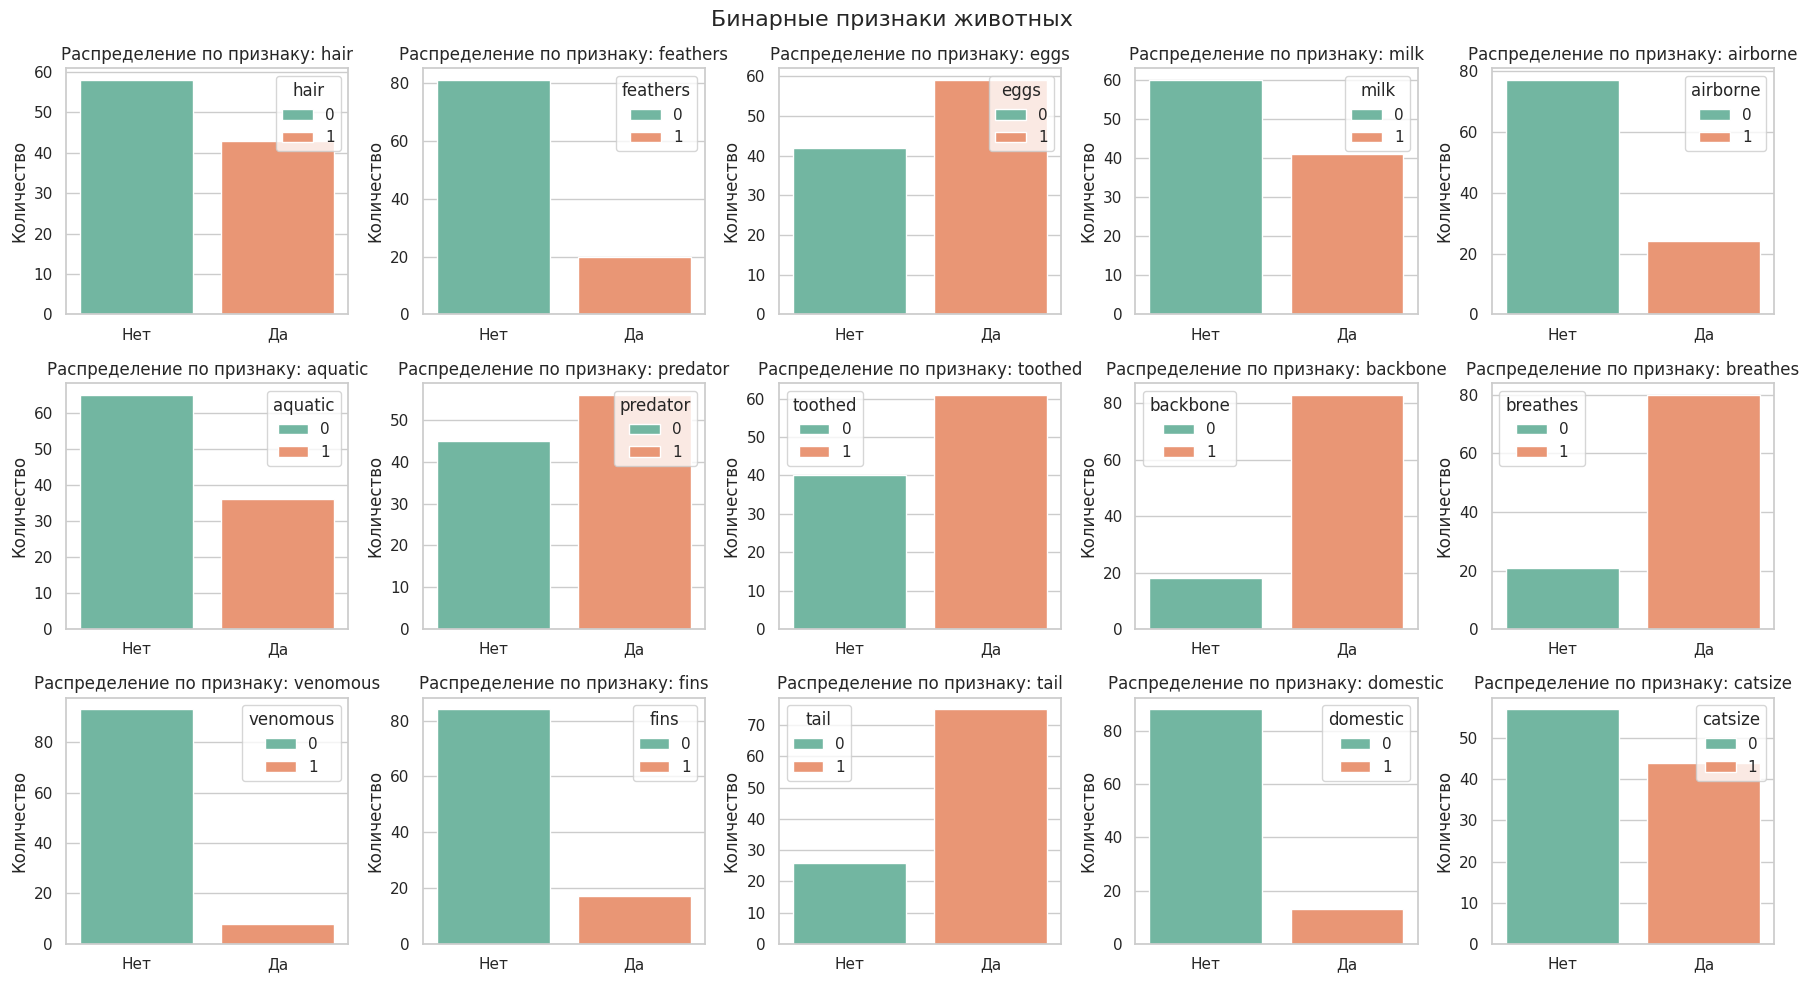

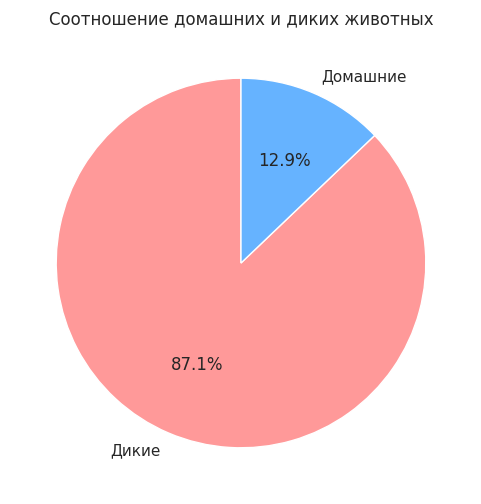

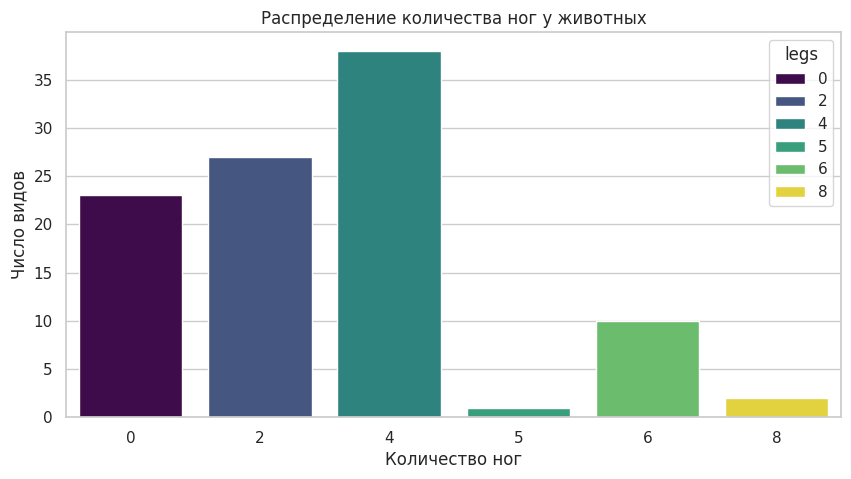

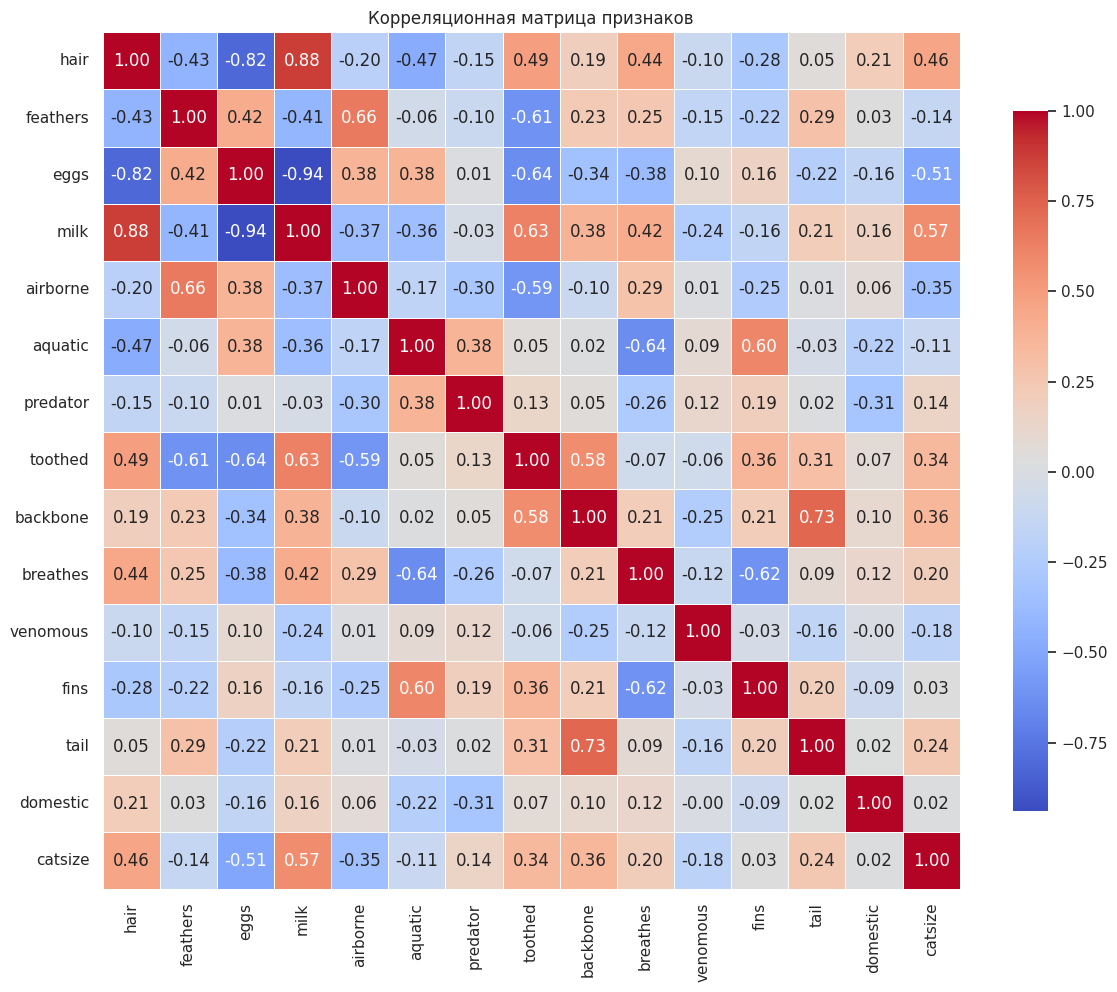

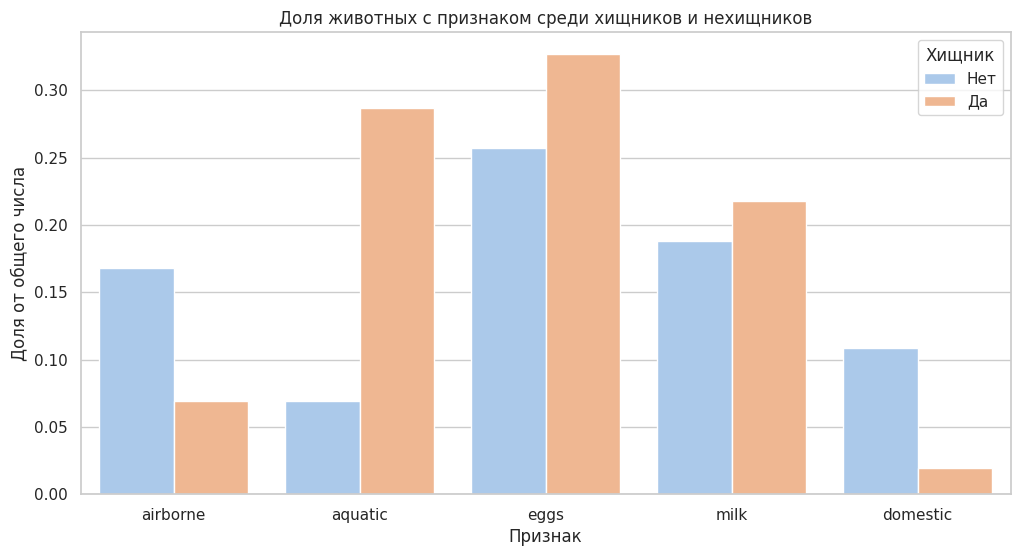

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import shutil
from google.colab import files

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()
!kaggle datasets download -d raghunathangrdr/zoo-data-dataset

with zipfile.ZipFile('zoo-data-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('zoo-data-dataset')

    # Показать файлы в директории
print(os.listdir('zoo-data-dataset'))

# Замените 'zoo_data-1.csv' на правильное имя файла
df = pd.read_csv('zoo-data-dataset/zoo_data-1.csv')

# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())

# ---------- 1. Подключение к БД и создание таблицы ----------
# Создаём (или подключаемся) файл базы данных zoo.db
conn = sqlite3.connect('zoo.db')
cursor = conn.cursor()


# Создание таблицы
cursor.execute('''
  CREATE TABLE IF NOT EXISTS zoo (animal_id INTEGER PRIMARY KEY,
    animal_name TEXT,
    eggs INTEGER,
    milk INTEGER,
    airborne INTEGER,
    aquatic INTEGER,
    predator INTEGER,
    domestic INTEGER
  )
''')
conn.commit()

# Импорт данных
df [['animal_name', 'eggs','milk', 'airborne', 'aquatic', 'predator', 'domestic']].to_sql('zoo', conn, if_exists='replace', index=False)
conn.commit()

# Определяем функцию для выполнения запросов
def execute_query(query):
    cursor.execute(query)
    return cursor.fetchall()

# Определяем животных, которые одомашнены
print("Домашнее животное")
print(pd.read_sql("SELECT animal_name FROM zoo WHERE domestic = 1", conn))

# определим водоплавающих хищников
print("Водоплавающие хищники")
print(pd.read_sql("SELECT animal_name FROM zoo WHERE predator =1 AND aquatic =1", conn))

# Посчитаем количество животных, несущих яйца
print("животные, несущие яйца")
print(pd.read_sql("SELECT COUNT(*) FROM zoo WHERE eggs=1", conn))

# ---------- 2. Визуализация данных ----------

# Стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Количество животных по каждому бинарному признаку (кроме 'legs')
binary_features = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
                   'predator', 'toothed', 'backbone', 'breathes', 'venomous',
                   'fins', 'tail', 'domestic', 'catsize']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(binary_features):
    ax = axes[i]
    sns.countplot(data=df, x=feat, hue=feat, ax=ax, palette='Set2')
    ax.set_title(f'Распределение по признаку: {feat}')
    ax.set_xlabel('')
    ax.set_ylabel('Количество')
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Нет', 'Да'])  # т.к. значения 0/1


# Убираем лишние пустые графики (если features меньше 15)
for j in range(len(binary_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Бинарные признаки животных', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Круговая диаграмма: домашние vs дикие
domestic_counts = df['domestic'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(domestic_counts, labels=['Дикие', 'Домашние'], autopct='%1.1f%%',
        startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Соотношение домашних и диких животных')
plt.show()

# 3. Гистограмма количества ног (legs)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='legs', hue= 'legs', palette='viridis')
plt.title('Распределение количества ног у животных')
plt.xlabel('Количество ног')
plt.ylabel('Число видов')
plt.show()

# 4. Тепловая карта корреляций между бинарными признаками
# Вычислим корреляционную матрицу (для бинарных данных подойдёт)
corr = df[binary_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

# 5. (Дополнительно) Сравнение хищников и нехищников по другим признакам
# Построим grouped bar plot для нескольких ключевых признаков
predator_features = ['airborne', 'aquatic', 'eggs', 'milk', 'domestic']
df_melted = df.melt(id_vars=['animal_name', 'predator'],
                    value_vars=predator_features,
                    var_name='признак', value_name='наличие')

plt.figure(figsize=(12,6))
sns.barplot(data=df_melted[df_melted['наличие']==1], x='признак', y='наличие',
            hue='predator', estimator=lambda x: len(x)/len(df), errorbar=None,
            palette='pastel')
plt.title('Доля животных с признаком среди хищников и нехищников')
plt.ylabel('Доля от общего числа')
plt.xlabel('Признак')
plt.legend(title='Хищник', labels=['Нет', 'Да'])
plt.show()
conn.close()
